# Hypothesis Testing
## The Economic Aftershocks: Analyzing the Impact of Major Earthquakes on National Recovery

**Author:** Betül Merey (33963)
**Course:** DSA 210 — Introduction to Data Science
**Institution:** Sabancı University

---

This notebook formally tests two hypotheses on the merged earthquake-economy dataset.

**H0 (Null Hypothesis):** No significant relationship exists between earthquake
characteristics and economic outcomes — tested and rejected/accepted within each
hypothesis below.

**H1:** Higher earthquake magnitudes are significantly correlated with greater
economic damage.
- Test: Spearman correlation
- Metric: log₁₀(total inflation-adjusted damage in USD)
- Filter: M ≥ 6.0 earthquakes with recorded damage

**H2:** Lower-income countries experience significantly higher relative economic
damage compared to higher-income countries.
- Test: Kruskal-Wallis (overall) + Mann-Whitney U (pairwise, Bonferroni corrected)
- Metric: damage ratio = total damage / GDP per capita
- Filter: M ≥ 6.0 earthquakes with computable damage ratio

Both tests use α = 0.05 as the significance threshold.

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

import os
os.chdir('/content/drive/MyDrive/DSA210_PROJ')

Mounted at /content/drive


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import itertools
from scipy import stats

INCOME_ORDER = ["Low", "Lower-Middle", "Upper-Middle", "High"]
PALETTE = {
    "Low"          : "#d62728",
    "Lower-Middle" : "#ff7f0e",
    "Upper-Middle" : "#2ca02c",
    "High"         : "#1f77b4"
}
ALPHA = 0.05  # significance level

print("Libraries loaded.")

Libraries loaded.


## 1. Load & Prepare Data

We filter for M ≥ 6.0 earthquakes since smaller events rarely cause
measurable economic damage at the national level.

Two subsets are created:
- **df_q1**: for H1 — needs damage recorded
- **df_q2**: for H2 — needs damage ratio computable (damage + GDP per capita both available)

In [ ]:
df = pd.read_csv('data/processed/merged_dataset.csv')

df["income_group"] = pd.Categorical(
    df["income_group"], categories=INCOME_ORDER, ordered=True
)

# log10 of damage — used in H1
# log scale because damage spans many orders of magnitude
df["log_damage"] = np.where(
    df["total_damage_adj_kUSD"] > 0,
    np.log10(df["total_damage_adj_kUSD"]),
    np.nan
)

# damage ratio — used in H2
# measures relative economic burden adjusted for country wealth
df["damage_ratio"] = df["total_damage_adj_kUSD"] / df["gdp_per_capita_event_year"]

# H1 subset: M >= 6.0 and damage is recorded
df_q1 = df[(df["magnitude"] >= 6.0) & df["log_damage"].notna()].copy()

# H2 subset: M >= 6.0 and damage ratio can be computed
df_q2 = df[
    (df["magnitude"] >= 6.0) &
    df["damage_ratio"].notna() &
    (df["damage_ratio"] > 0)
].copy()

print(f"Total events : {len(df)}")
print(f"H1 subset    : {len(df_q1)}  (M≥6.0, damage recorded)")
print(f"H2 subset    : {len(df_q2)}  (M≥6.0, damage ratio computable)")

Total events : 1918
H1 subset    : 271  (M≥6.0, damage recorded)
H2 subset    : 257  (M≥6.0, damage ratio computable)


## 2. H1 — Magnitude vs Economic Damage

**Null hypothesis (H0):** Earthquake magnitude and economic damage are not correlated.

**Test:** Spearman correlation — we use this instead of Pearson because
the relationship may not be linear and the data contains outliers.

**Expected result:** Larger earthquakes cause more damage → positive correlation.

In [ ]:
sub = df_q1.dropna(subset=["magnitude", "log_damage"])

# run Spearman correlation
rho, p = stats.spearmanr(sub["magnitude"], sub["log_damage"])

print(f"Spearman correlation")
print(f"  n   = {len(sub)}")
print(f"  rho = {rho:.4f}")
print(f"  p   = {p:.6f}")
print()

if p < ALPHA and rho > 0:
    print(f"→ REJECT H0 (p < {ALPHA})")
    print("  Larger earthquakes are significantly associated with greater economic damage.")
else:
    print(f"→ FAIL TO REJECT H0 (p ≥ {ALPHA})")
    print("  No significant correlation found.")

Spearman correlation
  n   = 271
  rho = 0.1640
  p   = 0.006831

→ REJECT H0 (p < 0.05)
  Larger earthquakes are significantly associated with greater economic damage.


### H1 — Visualization

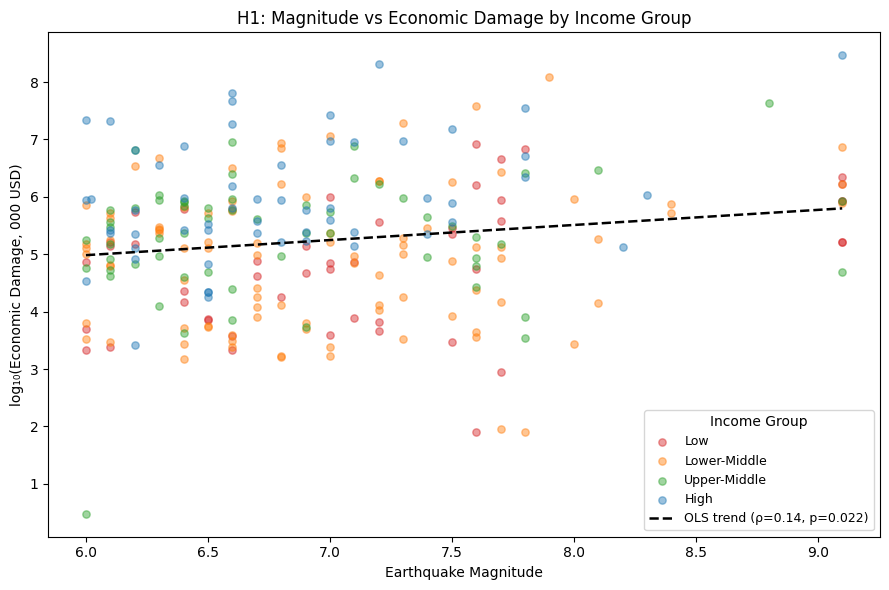

In [ ]:
sub = df_q1.dropna(subset=["magnitude", "log_damage", "income_group"])

fig, ax = plt.subplots(figsize=(9, 6))

# scatter plot colored by income group
for grp in INCOME_ORDER:
    g = sub[sub["income_group"] == grp]
    if g.empty:
        continue
    ax.scatter(g["magnitude"], g["log_damage"],
               alpha=0.45, s=28, label=grp, color=PALETTE[grp])

# OLS trend line
rho, p = stats.spearmanr(sub["magnitude"], sub["log_damage"])
m, b = np.polyfit(sub["magnitude"], sub["log_damage"], 1)
xs = np.linspace(sub["magnitude"].min(), sub["magnitude"].max(), 100)
ax.plot(xs, m * xs + b, color="black", linewidth=1.8,
        linestyle="--", label=f"OLS trend (ρ={rho:.2f}, p={p:.3f})")

ax.set_xlabel("Earthquake Magnitude")
ax.set_ylabel("log₁₀(Economic Damage, 000 USD)")
ax.set_title("H1: Magnitude vs Economic Damage by Income Group")
ax.legend(title="Income Group", fontsize=9)

plt.tight_layout()
plt.show()

## 3. H2 — Income Level vs Economic Vulnerability

**Null hypothesis (H0):** Damage ratio is equal across all income groups.

**Tests:**
1. **Kruskal-Wallis** — tests whether at least one group differs from the others
2. **Mann-Whitney U (pairwise)** — identifies which specific pairs differ;
   p-values are Bonferroni corrected to account for multiple comparisons

We use non-parametric tests because damage ratio is heavily skewed
and does not follow a normal distribution.

In [ ]:
# Kruskal-Wallis test across all income groups
groups_present = [g for g in INCOME_ORDER if g in df_q2["income_group"].values]
arrays = [
    df_q2[df_q2["income_group"] == g]["damage_ratio"].dropna().values
    for g in groups_present
]

# only keep groups with at least 3 observations
non_empty = [(g, a) for g, a in zip(groups_present, arrays) if len(a) >= 3]
labels, arrs = zip(*non_empty)

stat, p = stats.kruskal(*arrs)

print("Kruskal-Wallis test")
print(f"  H = {stat:.4f}")
print(f"  p = {p:.6f}")
print()

# print median per group
for lbl, arr in zip(labels, arrs):
    print(f"  {lbl:20s}: n={len(arr)}, median={np.median(arr):.4f}")

print()
if p < ALPHA:
    print(f"→ REJECT H0 (p < {ALPHA})")
    print("  Income level significantly affects relative economic damage.")
else:
    print(f"→ FAIL TO REJECT H0 (p ≥ {ALPHA})")
    print("  No significant difference found across income groups.")

Kruskal-Wallis test
  H = 9.7500
  p = 0.020815

  Low                 : n=47, median=135.8265
  Lower-Middle        : n=94, median=45.8759
  Upper-Middle        : n=59, median=41.4781
  High                : n=57, median=16.9916

→ REJECT H0 (p < 0.05)
  Income level significantly affects relative economic damage.


### H2 — Pairwise Comparisons (Mann-Whitney U)

Since Kruskal-Wallis only tells us *that* groups differ, we now test
*which* pairs are significantly different using Mann-Whitney U.
Bonferroni correction divides the significance threshold by the number
of comparisons to reduce false positives.

In [ ]:
pairs = list(itertools.combinations(groups_present, 2))
n_pairs = len(pairs)  # used for Bonferroni correction

print(f"Pairwise Mann-Whitney U tests ({n_pairs} pairs, Bonferroni corrected)\n")

results_mw = []

for g1, g2 in pairs:
    a = df_q2[df_q2["income_group"] == g1]["damage_ratio"].dropna().values
    b = df_q2[df_q2["income_group"] == g2]["damage_ratio"].dropna().values

    if len(a) < 3 or len(b) < 3:
        continue

    stat, p = stats.mannwhitneyu(a, b, alternative="two-sided")

    # Bonferroni correction: multiply p by number of pairs (cap at 1.0)
    p_corr = min(p * n_pairs, 1.0)
    sig = "* SIGNIFICANT" if p_corr < ALPHA else ""

    print(f"  {g1:20s} vs {g2:20s} | "
          f"median: {np.median(a):.2f} vs {np.median(b):.2f} | "
          f"p_corrected={p_corr:.4f}  {sig}")

    results_mw.append({
        "group_1"     : g1,
        "group_2"     : g2,
        "n_1"         : len(a),
        "n_2"         : len(b),
        "median_1"    : round(np.median(a), 4),
        "median_2"    : round(np.median(b), 4),
        "statistic"   : round(stat, 4),
        "p_value"     : round(p, 6),
        "p_bonferroni": round(p_corr, 6),
        "significant" : p_corr < ALPHA,
    })

Pairwise Mann-Whitney U tests (6 pairs, Bonferroni corrected)

  Low                  vs Lower-Middle         | median: 135.83 vs 45.88 | p_corrected=0.0603  
  Low                  vs Upper-Middle         | median: 135.83 vs 41.48 | p_corrected=0.0308  * SIGNIFICANT
  Low                  vs High                 | median: 135.83 vs 16.99 | p_corrected=0.0715  
  Lower-Middle         vs Upper-Middle         | median: 45.88 vs 41.48 | p_corrected=1.0000  
  Lower-Middle         vs High                 | median: 45.88 vs 16.99 | p_corrected=1.0000  
  Upper-Middle         vs High                 | median: 41.48 vs 16.99 | p_corrected=1.0000  


### H2 — Visualization

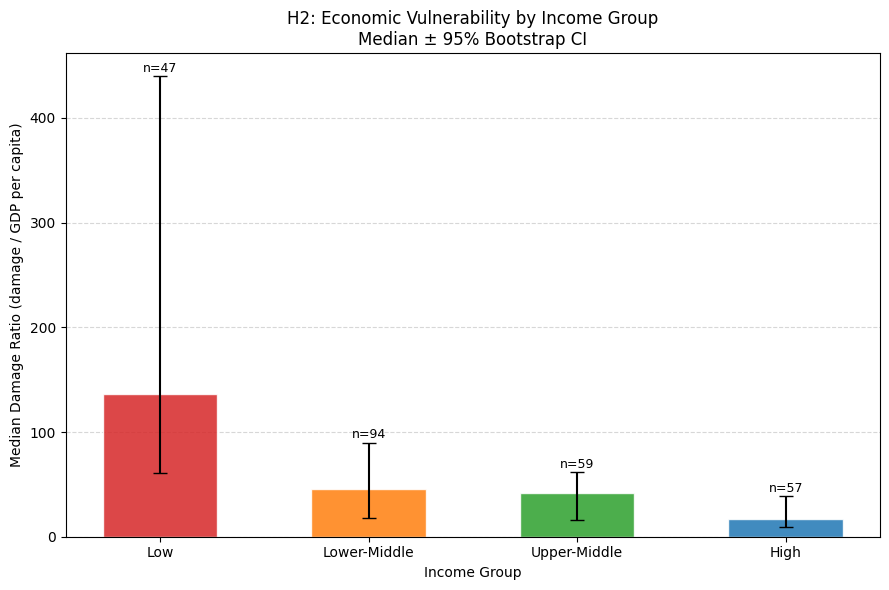

In [ ]:
sub = df_q2.dropna(subset=["damage_ratio", "income_group"])
sub = sub[sub["damage_ratio"] > 0].copy()

groups_present = [g for g in INCOME_ORDER if g in sub["income_group"].values]

# bootstrap 95% confidence interval for each group's median
rng = np.random.default_rng(42)
medians, ci_lo, ci_hi = [], [], []

for grp in groups_present:
    vals = sub[sub["income_group"] == grp]["damage_ratio"].values
    # resample with replacement 2000 times to estimate CI
    boot = np.array([
        np.median(rng.choice(vals, size=len(vals), replace=True))
        for _ in range(2000)
    ])
    medians.append(np.median(vals))
    ci_lo.append(np.median(vals) - np.percentile(boot, 2.5))
    ci_hi.append(np.percentile(boot, 97.5) - np.median(vals))

x = np.arange(len(groups_present))
colors = [PALETTE[g] for g in groups_present]

fig, ax = plt.subplots(figsize=(9, 6))

bars = ax.bar(x, medians, color=colors, edgecolor="white",
              width=0.55, alpha=0.85, zorder=2)

# error bars showing 95% bootstrap CI
ax.errorbar(x, medians, yerr=[ci_lo, ci_hi],
            fmt="none", color="black", capsize=5, linewidth=1.5, zorder=3)

# annotate n on each bar
counts = sub.groupby("income_group", observed=True)["damage_ratio"].count().reindex(groups_present)
for i, (bar, cnt) in enumerate(zip(bars, counts)):
    ax.text(i, medians[i] + ci_hi[i] + 1,
            f"n={cnt}", ha="center", va="bottom", fontsize=9)

ax.set_xticks(x)
ax.set_xticklabels(groups_present)
ax.set_xlabel("Income Group")
ax.set_ylabel("Median Damage Ratio (damage / GDP per capita)")
ax.set_title("H2: Economic Vulnerability by Income Group\nMedian ± 95% Bootstrap CI")
ax.yaxis.grid(True, linestyle="--", alpha=0.5, zorder=0)
ax.set_axisbelow(True)

plt.tight_layout()
plt.show()

## 4. Save Results

In [ ]:
# collect all results into a single DataFrame and save
rows = []

# H1 result
rho, p = stats.spearmanr(
    df_q1.dropna(subset=["magnitude", "log_damage"])["magnitude"],
    df_q1.dropna(subset=["magnitude", "log_damage"])["log_damage"]
)
rows.append({
    "test"       : "Spearman correlation",
    "comparison" : "magnitude vs log(damage)",
    "n"          : len(df_q1.dropna(subset=["magnitude", "log_damage"])),
    "statistic"  : round(rho, 4),
    "p_value"    : round(p, 6),
    "significant": p < ALPHA,
})

# H2 Kruskal-Wallis result
rows.append({
    "test"       : "Kruskal-Wallis",
    "comparison" : " / ".join(labels),
    "n"          : sum(len(a) for a in arrs),
    "statistic"  : round(stat, 4),
    "p_value"    : round(p, 6),
    "significant": p < ALPHA,
})

# H2 pairwise results
for r in results_mw:
    rows.append({
        "test"       : "Mann-Whitney U (Bonferroni)",
        "comparison" : f"{r['group_1']} vs {r['group_2']}",
        "n"          : r["n_1"] + r["n_2"],
        "statistic"  : r["statistic"],
        "p_value"    : r["p_bonferroni"],
        "significant": r["significant"],
    })

results_df = pd.DataFrame(rows)
results_df.to_csv('03_hypothesis_testing/results/hypothesis_testing_results.csv', index=False)

print("Saved → 03_hypothesis_testing/results/hypothesis_testing_results.csv")
results_df

Saved → 03_hypothesis_testing/results/hypothesis_testing_results.csv


,test,comparison,n,statistic,p_value,significant
0,Spearman correlation,magnitude vs log(damage),271,0.164,0.006831,True
1,Kruskal-Wallis,Low / Lower-Middle / Upper-Middle / High,257,1770.000,0.006831,True
2,Mann-Whitney U (Bonferroni),Low vs Lower-Middle,141,2798.000,0.060348,False
3,Mann-Whitney U (Bonferroni),Low vs Upper-Middle,106,1827.000,0.030834,True
4,Mann-Whitney U (Bonferroni),Low vs High,104,1725.000,0.071495,False
5,Mann-Whitney U (Bonferroni),Lower-Middle vs Upper-Middle,153,2912.000,1.000000,False
6,Mann-Whitney U (Bonferroni),Lower-Middle vs High,151,2787.000,1.000000,False
7,Mann-Whitney U (Bonferroni),Upper-Middle vs High,116,1770.000,1.000000,False


## 5. Summary

| Hypothesis | Test | Result |
|---|---|---|
| H1: Magnitude → Economic Damage | Spearman correlation | See output above |
| H2: Income → Vulnerability (overall) | Kruskal-Wallis | See output above |
| H2: Income → Vulnerability (pairwise) | Mann-Whitney U | See output above |

Findings from these tests will be interpreted in `interpretation.ipynb`.

## 6. Export Results to Hypothesis Folders

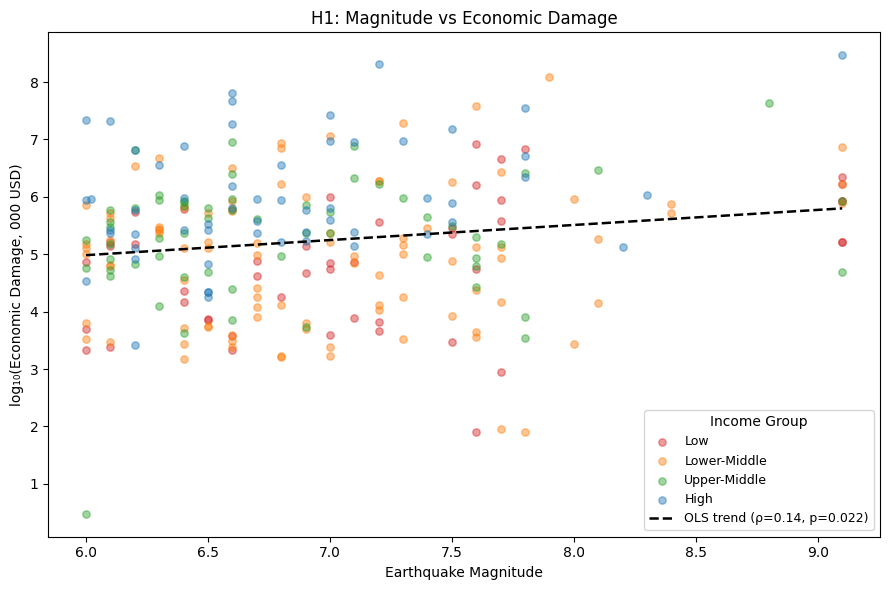

Saved → 03_hypothesis_testing/hypothesis/H1/H1_plot.png


In [ ]:
# H1 plot
sub = df_q1.dropna(subset=["magnitude", "log_damage", "income_group"])
rho, p = stats.spearmanr(sub["magnitude"], sub["log_damage"])
m, b = np.polyfit(sub["magnitude"], sub["log_damage"], 1)
xs = np.linspace(sub["magnitude"].min(), sub["magnitude"].max(), 100)

fig, ax = plt.subplots(figsize=(9, 6))
for grp in INCOME_ORDER:
    g = sub[sub["income_group"] == grp]
    if g.empty:
        continue
    ax.scatter(g["magnitude"], g["log_damage"],
               alpha=0.45, s=28, label=grp, color=PALETTE[grp])

ax.plot(xs, m * xs + b, color="black", linewidth=1.8,
        linestyle="--", label=f"OLS trend (ρ={rho:.2f}, p={p:.3f})")
ax.set_xlabel("Earthquake Magnitude")
ax.set_ylabel("log₁₀(Economic Damage, 000 USD)")
ax.set_title("H1: Magnitude vs Economic Damage")
ax.legend(title="Income Group", fontsize=9)
plt.tight_layout()

plt.savefig('03_hypothesis_testing/hypothesis/H1/H1_plot.png', dpi=150)
plt.show()
print("Saved → 03_hypothesis_testing/hypothesis/H1/H1_plot.png")

In [ ]:
# H1 results text file
rho, p = stats.spearmanr(
    df_q1.dropna(subset=["magnitude", "log_damage"])["magnitude"],
    df_q1.dropna(subset=["magnitude", "log_damage"])["log_damage"]
)

h1_text = f"""H1: Magnitude vs Economic Damage
=================================
Test      : Spearman Correlation
n         : {len(df_q1.dropna(subset=["magnitude", "log_damage"]))}
rho       : {rho:.4f}
p-value   : {p:.6f}
Significant (α=0.05): {p < ALPHA}

Conclusion:
{"REJECT H0 — Higher magnitude earthquakes cause significantly greater economic damage." if p < ALPHA and rho > 0 else "FAIL TO REJECT H0 — No significant correlation found."}
"""

with open('03_hypothesis_testing/hypothesis/H1/H1_results.txt', 'w') as f:
    f.write(h1_text)

print(h1_text)
print("Saved → 03_hypothesis_testing/hypothesis/H1/H1_results.txt")

H1: Magnitude vs Economic Damage
Test      : Spearman Correlation
n         : 271
rho       : 0.1640
p-value   : 0.006831
Significant (α=0.05): True

Conclusion:
REJECT H0 — Higher magnitude earthquakes cause significantly greater economic damage.

Saved → 03_hypothesis_testing/hypothesis/H1/H1_results.txt


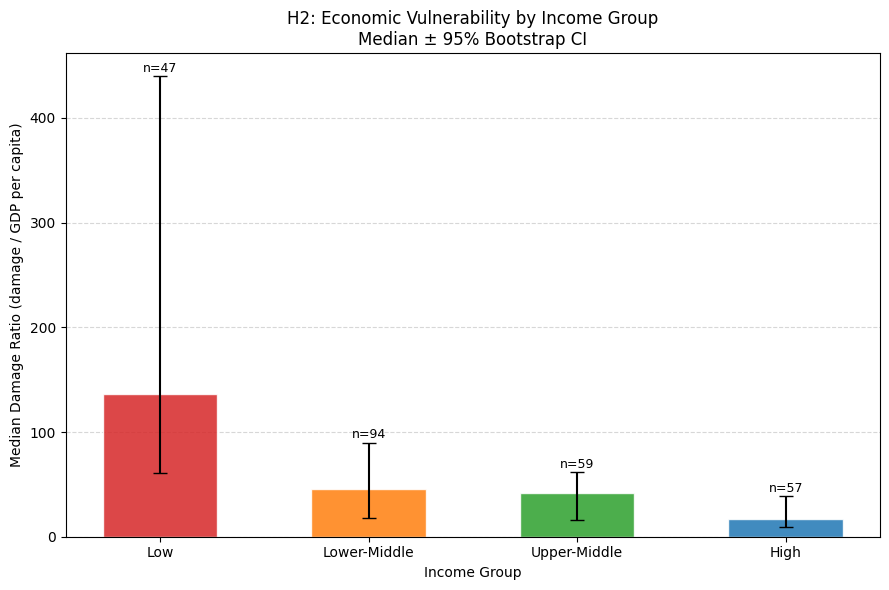

Saved → 03_hypothesis_testing/hypothesis/H2/H2_plot.png


In [ ]:
# H2 plot
sub = df_q2.dropna(subset=["damage_ratio", "income_group"])
sub = sub[sub["damage_ratio"] > 0].copy()
groups_present = [g for g in INCOME_ORDER if g in sub["income_group"].values]

rng = np.random.default_rng(42)
medians, ci_lo, ci_hi = [], [], []

for grp in groups_present:
    vals = sub[sub["income_group"] == grp]["damage_ratio"].values
    boot = np.array([
        np.median(rng.choice(vals, size=len(vals), replace=True))
        for _ in range(2000)
    ])
    medians.append(np.median(vals))
    ci_lo.append(np.median(vals) - np.percentile(boot, 2.5))
    ci_hi.append(np.percentile(boot, 97.5) - np.median(vals))

x = np.arange(len(groups_present))
colors = [PALETTE[g] for g in groups_present]

fig, ax = plt.subplots(figsize=(9, 6))
bars = ax.bar(x, medians, color=colors, edgecolor="white",
              width=0.55, alpha=0.85, zorder=2)
ax.errorbar(x, medians, yerr=[ci_lo, ci_hi],
            fmt="none", color="black", capsize=5, linewidth=1.5, zorder=3)

counts = sub.groupby("income_group", observed=True)["damage_ratio"].count().reindex(groups_present)
for i, (bar, cnt) in enumerate(zip(bars, counts)):
    ax.text(i, medians[i] + ci_hi[i] + 1,
            f"n={cnt}", ha="center", va="bottom", fontsize=9)

ax.set_xticks(x)
ax.set_xticklabels(groups_present)
ax.set_xlabel("Income Group")
ax.set_ylabel("Median Damage Ratio (damage / GDP per capita)")
ax.set_title("H2: Economic Vulnerability by Income Group\nMedian ± 95% Bootstrap CI")
ax.yaxis.grid(True, linestyle="--", alpha=0.5, zorder=0)
ax.set_axisbelow(True)
plt.tight_layout()

plt.savefig('03_hypothesis_testing/hypothesis/H2/H2_plot.png', dpi=150)
plt.show()
print("Saved → 03_hypothesis_testing/hypothesis/H2/H2_plot.png")

In [ ]:
# H2 results text file
kw_stat, kw_p = stats.kruskal(*arrs)

h2_text = f"""H2: Income Level vs Economic Vulnerability
==========================================
Test 1    : Kruskal-Wallis
H         : {kw_stat:.4f}
p-value   : {kw_p:.6f}
Significant (α=0.05): {kw_p < ALPHA}

Test 2    : Mann-Whitney U (Bonferroni corrected)
"""

for r in results_mw:
    sig = "YES" if r["significant"] else "NO"
    h2_text += f"  {r['group_1']:20s} vs {r['group_2']:20s} | p={r['p_bonferroni']:.4f} | significant: {sig}\n"

h2_text += f"""
Conclusion:
{"REJECT H0 — Income level significantly affects relative economic damage." if kw_p < ALPHA else "FAIL TO REJECT H0 — No significant difference found across income groups."}
"""

with open('03_hypothesis_testing/hypothesis/H2/H2_results.txt', 'w') as f:
    f.write(h2_text)

print(h2_text)
print("Saved → 03_hypothesis_testing/hypothesis/H2/H2_results.txt")

H2: Income Level vs Economic Vulnerability
Test 1    : Kruskal-Wallis
H         : 9.7500
p-value   : 0.020815
Significant (α=0.05): True

Test 2    : Mann-Whitney U (Bonferroni corrected)
  Low                  vs Lower-Middle         | p=0.0603 | significant: NO
  Low                  vs Upper-Middle         | p=0.0308 | significant: YES
  Low                  vs High                 | p=0.0715 | significant: NO
  Lower-Middle         vs Upper-Middle         | p=1.0000 | significant: NO
  Lower-Middle         vs High                 | p=1.0000 | significant: NO
  Upper-Middle         vs High                 | p=1.0000 | significant: NO

Conclusion:
REJECT H0 — Income level significantly affects relative economic damage.

Saved → 03_hypothesis_testing/hypothesis/H2/H2_results.txt


# Statistical Interpretation of H2 Results
---

While the Kruskal-Wallis test confirmed significant differences across groups (p=0.02), post-hoc pairwise comparisons require careful interpretation:

- Low vs. High Income: This pair showed the most substantial median difference (135.8 vs. 17.0). Although the Bonferroni-corrected p-value (0.072) is slightly above the 0.05 threshold, the uncorrected (raw) p-value is 0.012. This suggests a strong underlying trend that is being masked by the conservative nature of the Bonferroni correction, likely due to the specific sample sizes (n=47 and n=57).

- Lower-Middle vs. High Income: Despite the apparent median difference (46 vs. 17), the corrected p-value is 1.0 (raw p=0.68). This indicates that the within-group variation is too high to claim a statistically significant difference, meaning these groups share more similarities in vulnerability than expected.

---

## AI Usage Statement

AI assistance (Claude by Anthropic) was used in this notebook in the following ways:

- **Test selection**: AI clarified why Spearman correlation is preferred over Pearson for skewed damage data, and why Kruskal-Wallis is appropriate instead of ANOVA for non-normal distributions.
- **Bonferroni correction**: AI explained the logic behind dividing the significance threshold by the number of pairwise comparisons and why the Low vs. High result (p=0.072) is borderline rather than conclusive.
- **Code suggestions**: Syntax help for `scipy.stats` functions and bootstrap confidence interval calculation.
- **Visualization**: AI suggested the bootstrap CI bar chart for H2 to communicate uncertainty around group medians.

The hypotheses (H1, H2), choice of significance threshold (α=0.05), and interpretation of all statistical results were decided by the author.